In [1]:
import os
import re
import pickle
import warnings
import time
import math
from collections import defaultdict
from difflib import get_close_matches

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import plotly.express as px
from scipy.spatial.distance import cdist
from scipy.sparse import csr_matrix
%matplotlib inline
warnings.filterwarnings('ignore')
pd.set_option('display.max_colwidth', 45)
pd.set_option('display.width', 220)

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA
from scipy.spatial.distance import cdist

import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from gensim.models import Word2Vec

# Download NLTK data (run once)
for pkg in ['punkt', 'stopwords', 'wordnet', 'punkt_tab']:
    nltk.download(pkg, quiet=True)

print('✅ All imports successful!')

✅ All imports successful!


In [2]:
DATA_DIR = '../data/raw/'

data       = pd.read_csv(DATA_DIR + 'data.csv')
genre_data = pd.read_csv(DATA_DIR + 'data_by_genres.csv')
year_data  = pd.read_csv(DATA_DIR + 'data_by_year.csv')
lyrics_raw = pd.read_csv(DATA_DIR + 'spotify_songs.csv')

print('=' * 58)
print('DATASET SUMMARY')
print('=' * 58)
print(f'  Main audio data (C matrix) : {data.shape[0]:>7,} songs  × {data.shape[1]} cols')
print(f'  Genre aggregates           : {genre_data.shape[0]:>7,} genres × {genre_data.shape[1]} cols')
print(f'  Year aggregates            : {year_data.shape[0]:>7,} years  × {year_data.shape[1]} cols')
print(f'  Lyrics + playlists (R+L)   : {lyrics_raw.shape[0]:>7,} songs  × {lyrics_raw.shape[1]} cols')
print()
print('Lyrics dataset columns:', lyrics_raw.columns.tolist())

DATASET SUMMARY
  Main audio data (C matrix) : 170,653 songs  × 19 cols
  Genre aggregates           :   2,973 genres × 14 cols
  Year aggregates            :     100 years  × 14 cols
  Lyrics + playlists (R+L)   :  18,454 songs  × 25 cols

Lyrics dataset columns: ['track_id', 'track_name', 'track_artist', 'lyrics', 'track_popularity', 'track_album_id', 'track_album_name', 'track_album_release_date', 'playlist_name', 'playlist_id', 'playlist_genre', 'playlist_subgenre', 'danceability', 'energy', 'key', 'loudness', 'mode', 'speechiness', 'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo', 'duration_ms', 'language']


In [3]:
print('Clustering genres...')
cluster_pipeline = make_pipeline(
    StandardScaler(),
    KMeans(n_clusters=10, random_state=42, n_init=10)
)
genre_data['cluster'] = cluster_pipeline.fit_predict(
    genre_data.select_dtypes(include=[np.number])
)
print(f'✅ Genre clustering: 10 clusters on {len(genre_data):,} genres')

Clustering genres...
✅ Genre clustering: 10 clusters on 2,973 genres


In [4]:
print('Running t-SNE on genres (takes ~30s)...')
tsne_pipeline = make_pipeline(StandardScaler(),TSNE(n_components=2, verbose=0, random_state=42))
projection = pd.DataFrame(
    tsne_pipeline.fit_transform(genre_data.select_dtypes(include=[np.number])),
    columns=['x', 'y']
)
projection['genres']  = genre_data['genres']
projection['cluster'] = genre_data['cluster']

fig = px.scatter(
    projection, x='x', y='y', color='cluster',
    hover_data=['genres'],
    title='Genre Clusters (t-SNE)',
    template='plotly_white'
)
fig.show()

Running t-SNE on genres (takes ~30s)...


In [5]:
AUDIO_FEATURES = [
    'valence', 'year', 'acousticness', 'danceability', 'duration_ms',
    'energy', 'explicit', 'instrumentalness', 'key', 'liveness',
    'loudness', 'mode', 'popularity', 'speechiness', 'tempo'
]
available_features = [f for f in AUDIO_FEATURES if f in data.columns]
print(f'Using {len(available_features)} audio features for song clustering')

song_cluster_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('kmeans', KMeans(n_clusters=20, random_state=42, n_init=10, verbose=False))
])
X = data[available_features]
song_cluster_pipeline.fit(X)
data['cluster_label'] = song_cluster_pipeline.predict(X)
print('✅ Song clustering done — 20 clusters on 170k songs')

Using 15 audio features for song clustering
✅ Song clustering done — 20 clusters on 170k songs


In [6]:
pca_pipeline = Pipeline([('scaler', StandardScaler()), ('PCA', PCA(n_components=2))])
song_embedding = pca_pipeline.fit_transform(X)
song_proj = pd.DataFrame(song_embedding, columns=['x', 'y'])
song_proj['title']   = data['name']
song_proj['cluster'] = data['cluster_label']

fig = px.scatter(
    song_proj.sample(5000), x='x', y='y', color='cluster',
    hover_data=['title'],
    title='Song Clusters — PCA (5000 sample)',
    template='plotly_white'
)
fig.show()

In [7]:
lyrics_clean = lyrics_raw.rename(columns={
    'track_name':   'name',
    'track_artist': 'artist_name',
})

data['_name_key']           = data['name'].str.lower().str.strip()
lyrics_clean['_name_key']   = lyrics_clean['name'].str.lower().str.strip()

data['_artist_key'] = (
    data['artists']
    .str.replace(r"[\[\]']", '', regex=True)
    .str.split(',').str[0]
    .str.lower().str.strip()
)
lyrics_clean['_artist_key'] = lyrics_clean['artist_name'].str.lower().str.strip()

merged = pd.merge(
    data,
    lyrics_clean[['_name_key', '_artist_key', 'lyrics', 'language']],
    on=['_name_key', '_artist_key'],
    how='inner'
)
print(f"Merge 1 (name + artist): {len(merged)} songs")

if len(merged) < 500:
    print("Low match — trying name-only merge...")
    merged = pd.merge(
        data,
        lyrics_clean[['_name_key', 'lyrics', 'language']],
        on='_name_key',
        how='inner'
    )
    print(f"Merge 2 (name only): {len(merged)} songs")

merged = merged.drop(columns=['_name_key', '_artist_key'], errors='ignore')
data   = data.drop(columns=['_name_key', '_artist_key'], errors='ignore')
merged = merged.dropna(subset=['lyrics'])
merged = merged[merged['lyrics'].str.strip() != ''].reset_index(drop=True)

print(f"\n✅ Final: {len(merged):,} songs with audio + lyrics")
print(f"   Match rate: {len(merged)/len(data)*100:.1f}%")
merged[['name', 'artists', 'year', 'lyrics']].head(3)

Merge 1 (name + artist): 10994 songs

✅ Final: 10,960 songs with audio + lyrics
   Match rate: 6.4%


,name,artists,year,lyrics
0,Ain't No Sunshine,['Bill Withers'],1942,Ain't no sunshine when she's gone It's no...
1,The Devil Went Down to Georgia,['The Charlie Daniels Band'],1954,The Devil went down to Georgia. He was lo...
2,Long Tall Sally (The Thing),['Little Richard'],1957,Going to tell Aunt Mary about Uncle John ...


In [8]:
lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words('english'))

music_noise = {
    'verse', 'chorus', 'bridge', 'intro', 'outro', 'hook',
    'oh', 'ah', 'yeah', 'ooh', 'la', 'na', 'da', 'hey',
    'hmm', 'uh', 'woah', 'gonna', 'wanna', 'gotta', 'em', 'ima'
}
stop_words = stop_words.union(music_noise)


def preprocess_lyrics(text):
    """
    NLP preprocessing pipeline:
      1. Lowercase
      2. Remove special characters / numbers
      3. Tokenize
      4. Remove stopwords + music noise
      5. Lemmatize  (loved → love, running → run)
      6. Drop tokens shorter than 3 characters
    """
    if not isinstance(text, str) or len(text.strip()) == 0:
        return ''
    text   = text.lower()
    text   = re.sub(r'[^a-z\s]', ' ', text)
    tokens = word_tokenize(text)
    tokens = [t for t in tokens if t not in stop_words and len(t) > 2]
    tokens = [lemmatizer.lemmatize(t) for t in tokens]
    return ' '.join(tokens)


print('Preprocessing lyrics... (1–2 minutes)')
t0 = time.time()
merged['lyrics_clean'] = merged['lyrics'].apply(preprocess_lyrics)
print(f'✅ Done in {time.time()-t0:.1f}s')
print(f'\n[BEFORE]: {merged["lyrics"].iloc[0][:150]}')
print(f'[AFTER] : {merged["lyrics_clean"].iloc[0][:150]}')

Preprocessing lyrics... (1–2 minutes)
✅ Done in 11.5s

[BEFORE]: Ain't no sunshine when she's gone It's not warm when she's away Ain't no sunshine when she's gone And she's always gone too long anytime she goes away
[AFTER] : sunshine gone warm away sunshine gone always gone long anytime go away wonder time gone wonder gone stay sunshine gone house home anytime go away know


In [9]:
tfidf = TfidfVectorizer(
    max_features=5000,
    min_df=2,
    max_df=0.95,
    ngram_range=(1, 2),
    sublinear_tf=True
)

print('Building TF-IDF matrix...')
tfidf_matrix = tfidf.fit_transform(merged['lyrics_clean'])
print(f'✅ TF-IDF matrix: {tfidf_matrix.shape[0]:,} songs × {tfidf_matrix.shape[1]:,} lyric features')

feature_names   = tfidf.get_feature_names_out()
sample          = merged.iloc[0]
scores          = tfidf_matrix[0].toarray()[0]
top_idx         = scores.argsort()[-8:][::-1]

print(f'\nTop lyric keywords for: "{sample["name"]}"')
for i in top_idx:
    if scores[i] > 0:
        print(f'  {feature_names[i]:<25} {scores[i]:.4f}')

Building TF-IDF matrix...
✅ TF-IDF matrix: 10,960 songs × 5,000 lyric features

Top lyric keywords for: "Ain't No Sunshine"
  anytime                   0.4205
  know know                 0.3791
  sunshine                  0.3779
  go                        0.2701
  gone                      0.2483
  ought                     0.2094
  away know                 0.1994
  wonder                    0.1973


In [10]:
SIMILARITY_FEATURES = [
    'valence', 'acousticness', 'danceability', 'energy',
    'instrumentalness', 'liveness', 'loudness', 'speechiness', 'tempo'
]
sim_features = [f for f in SIMILARITY_FEATURES if f in merged.columns]

scaler       = StandardScaler()
audio_matrix = scaler.fit_transform(merged[sim_features])

print(f'✅ C matrix (audio/song characteristics): {audio_matrix.shape[0]:,} × {audio_matrix.shape[1]}')
print(f'   Features: {sim_features}')

✅ C matrix (audio/song characteristics): 10,960 × 9
   Features: ['valence', 'acousticness', 'danceability', 'energy', 'instrumentalness', 'liveness', 'loudness', 'speechiness', 'tempo']


In [11]:
print('Step 1: Tokenizing lyrics for Word2Vec...')
tokenized_lyrics = [
    text.split() for text in merged['lyrics_clean']
    if isinstance(text, str) and len(text.strip()) > 10
]
print(f'  → {len(tokenized_lyrics):,} songs ready')
print(f'  → Sample: {tokenized_lyrics[0][:10]}')

print('\nStep 2: Training Word2Vec (2-3 mins)...')
t0 = time.time()
w2v_model = Word2Vec(
    sentences=tokenized_lyrics, vector_size=100, window=5,
    min_count=2, workers=4, sg=1, epochs=15, seed=42
)
print(f'  ✅ Trained in {time.time()-t0:.1f}s')
print(f'  → Vocabulary: {len(w2v_model.wv):,} unique music words')

print('\nStep 3: Semantic relationships Word2Vec learned:')
for word in ['love', 'heart', 'dance', 'pain', 'night']:
    if word in w2v_model.wv:
        sim = w2v_model.wv.most_similar(word, topn=3)
        print(f'  "{word}" → {[(w, round(s,2)) for w,s in sim]}')

def lyrics_to_vector(text, model, size=100):
    if not isinstance(text, str) or not text.strip():
        return np.zeros(size)
    vecs = [model.wv[w] for w in text.split() if w in model.wv]
    return np.mean(vecs, axis=0) if vecs else np.zeros(size)

print('\nStep 4: Building L matrix (avg pooling of word vectors)...')
L_matrix = np.vstack([lyrics_to_vector(t, w2v_model) for t in merged['lyrics_clean']])

norms = np.linalg.norm(L_matrix, axis=1, keepdims=True)
norms[norms == 0] = 1
L_matrix_norm = L_matrix / norms

print(f'  ✅ L matrix: {L_matrix_norm.shape[0]:,} songs × {L_matrix_norm.shape[1]} semantic dims')
print(f'     Non-zero: {(np.any(L_matrix != 0, axis=1)).sum():,} songs')

Step 1: Tokenizing lyrics for Word2Vec...
  → 10,956 songs ready
  → Sample: ['sunshine', 'gone', 'warm', 'away', 'sunshine', 'gone', 'always', 'gone', 'long', 'anytime']

Step 2: Training Word2Vec (2-3 mins)...


Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'


  ✅ Trained in 34.3s
  → Vocabulary: 28,248 unique music words

Step 3: Semantic relationships Word2Vec learned:
  "love" → [('know', 0.72), ('cause', 0.71), ('need', 0.69)]
  "heart" → [('mhmm', 0.75), ('forming', 0.69), ('apart', 0.67)]
  "dance" → [('hateration', 0.67), ('holleration', 0.67), ('withstand', 0.65)]
  "pain" → [('agai', 0.73), ('succumb', 0.66), ('oooohh', 0.63)]
  "night" → [('time', 0.66), ('day', 0.65), ('chiefing', 0.64)]

Step 4: Building L matrix (avg pooling of word vectors)...
  ✅ L matrix: 10,960 songs × 100 semantic dims
     Non-zero: 10,957 songs


In [12]:
print('CELL 12: Building R Matrix (CF via Playlist Co-occurrence)')
print('PDF Ref: Section 2.1 (R matrix) + Section 3.1 (confidence)')
print('='*60)

merged_names = set(merged['name'].str.lower().str.strip())
lyrics_cf    = lyrics_raw.copy()
lyrics_cf['_name_lower'] = lyrics_cf['track_name'].str.lower().str.strip()
lyrics_cf    = lyrics_cf[lyrics_cf['_name_lower'].isin(merged_names)]

R_df = lyrics_cf.pivot_table(
    index='playlist_name', columns='track_name',
    values='track_popularity', fill_value=0, aggfunc='count'
)
print(f'R matrix: {R_df.shape[0]} playlists × {R_df.shape[1]} songs')
sparsity = 100*(R_df==0).sum().sum()/(R_df.shape[0]*R_df.shape[1])
print(f'Sparsity: {sparsity:.1f}% zeros — normal for implicit feedback (PDF Section 8.7)')

alpha_cf = 10.0
R_values     = R_df.values.astype(np.float32)
R_confidence = 1.0 + alpha_cf * np.log1p(R_values)  # exact formula from PDF
print(f'\nConfidence weighting applied (αui = 1 + 10·log(1+rui)):')
print(f'  rui=0   → αui = 1.00')
print(f'  rui=50  → αui = {1+alpha_cf*np.log1p(50):.2f}')
print(f'  rui=100 → αui = {1+alpha_cf*np.log1p(100):.2f}')

print('\nComputing item-based CF similarity...')
R_sparse  = csr_matrix(R_confidence)
cf_sim_raw = cosine_similarity(R_sparse.T)  # songs × songs
cf_song_names = R_df.columns.tolist()
cf_sim_df = pd.DataFrame(cf_sim_raw, index=cf_song_names, columns=cf_song_names)
print(f'✅ CF similarity matrix: {cf_sim_df.shape[0]} × {cf_sim_df.shape[1]}')

for song in ['Despacito', 'Shape of You']:
    if song in cf_sim_df.index:
        top = cf_sim_df[song].sort_values(ascending=False)[1:4]
        print(f'\nCF top matches for "{song}":')
        for s, score in top.items():
            print(f'  {s:<40} {score:.4f}')

def get_cf_scores(song_name, all_song_names):
    """Returns CF similarity array aligned to merged dataset index"""
    scores = np.zeros(len(all_song_names))
    if song_name not in cf_sim_df.index:
        return scores
    for i, name in enumerate(all_song_names):
        if name in cf_sim_df.index:
            scores[i] = cf_sim_df.loc[song_name, name]
    return scores

print('\n✅ CF matrix ready. get_cf_scores() available.')

CELL 12: Building R Matrix (CF via Playlist Co-occurrence)
PDF Ref: Section 2.1 (R matrix) + Section 3.1 (confidence)
R matrix: 403 playlists × 6539 songs
Sparsity: 99.7% zeros — normal for implicit feedback (PDF Section 8.7)

Confidence weighting applied (αui = 1 + 10·log(1+rui)):
  rui=0   → αui = 1.00
  rui=50  → αui = 40.32
  rui=100 → αui = 47.15

Computing item-based CF similarity...
✅ CF similarity matrix: 6539 × 6539

CF top matches for "Despacito":
  What Makes You Beautiful                 1.0000
  This is Our Song - From "Camp Rock 2: The Final Jam" 0.9534
  They Don't Know About Us                 0.9534

CF top matches for "Shape of You":
  Love Is a Bitch                          0.9151
  3 Days                                   0.9151
  Quick Musical Doodles                    0.9151

✅ CF matrix ready. get_cf_scores() available.


In [13]:
def find_song_in_dataset(name, year, spotify_data, year_tolerance=2):
    match = spotify_data[
        (spotify_data['name'].str.lower() == name.lower()) &
        (spotify_data['year'] == year)
    ]
    if len(match) > 0:
        return match.iloc[0]
    year_matches = spotify_data[
        (spotify_data['year'] >= year - year_tolerance) &
        (spotify_data['year'] <= year + year_tolerance)
    ]
    if len(year_matches) > 0:
        close = get_close_matches(name, year_matches['name'].tolist(), n=1, cutoff=0.6)
        if close:
            row = year_matches[year_matches['name'] == close[0]]
            if len(row) > 0:
                print(f"  Fuzzy match: '{close[0]}' ({row.iloc[0]['year']})")
                return row.iloc[0]
    return None


def get_song_data(song, spotify_data):
    try:
        match = spotify_data[
            (spotify_data['name'] == song['name']) &
            (spotify_data['year'] == song['year'])
        ]
        if len(match) > 0:
            return match.iloc[0]
        return find_song_in_dataset(song['name'], song['year'], spotify_data)
    except Exception as e:
        print(f"Error: {e}")
        return None


def get_mean_vector(song_list, spotify_data):
    song_vectors, valid_songs = [], []
    for song in song_list:
        song_data = get_song_data(song, spotify_data)
        if song_data is None:
            print(f"  Warning: '{song['name']}' not found")
            continue
        song_vectors.append(song_data[available_features].values)
        valid_songs.append(song['name'])
    if not song_vectors:
        return None
    print(f"  Using: {valid_songs}")
    return np.mean(np.array(song_vectors), axis=0)


def flatten_dict_list(dict_list):
    if not dict_list:
        return defaultdict(list)
    result = defaultdict(list)
    for d in dict_list:
        for k, v in d.items():
            result[k].append(v)
    return result


def recommend_songs_phase1(song_list, spotify_data, n_songs=10):
    """Phase 1: Audio-only recommendation (original engine)"""
    song_dict   = flatten_dict_list(song_list)
    song_center = get_mean_vector(song_list, spotify_data)
    if song_center is None:
        return []
    scaler_p1     = song_cluster_pipeline.named_steps['scaler']
    scaled_data   = scaler_p1.transform(spotify_data[available_features])
    scaled_center = scaler_p1.transform(song_center.reshape(1, -1))
    distances     = cdist(scaled_center, scaled_data, 'cosine')
    index         = list(np.argsort(distances)[:, :n_songs + len(song_list)][0])
    rec_songs     = spotify_data.iloc[index]
    if song_dict['name']:
        rec_songs = rec_songs[~rec_songs['name'].isin(song_dict['name'])]
    return rec_songs[['name', 'year', 'artists']].head(n_songs).to_dict(orient='records')


print('✅ Phase 1 engine loaded')

✅ Phase 1 engine loaded


In [14]:
def get_song_index(song_name, data):
    exact = data[data['name'].str.lower() == song_name.lower()]
    if len(exact) > 0:
        return exact.sort_values('popularity', ascending=False).index[0]
    partial = data[data['name'].str.lower().str.contains(song_name.lower(), na=False)]
    if len(partial) > 0:
        return partial.sort_values('popularity', ascending=False).index[0]
    return None

def clean_results(result, input_idx, input_name):
    result = result.drop(index=input_idx)
    result = result.sort_values('hybrid_score', ascending=False)
    result = result.drop_duplicates(subset=['name'], keep='first')
    result = result[~result['name'].str.lower().str.startswith(input_name.lower() + ' -')]
    return result


def hybrid_recommend(song_name, data, audio_mat, lyric_mat,
                     audio_weight=0.5, lyric_weight=0.5, n=10):
    """
    Phase 2: Audio cosine + TF-IDF lyric cosine, fixed weights.
    hybrid = audio_w × audio_sim + lyric_w × lyric_sim
    """
    idx = get_song_index(song_name, data)
    if idx is None:
        print(f'⚠️  "{song_name}" not found in merged dataset')
        return None

    found = data.loc[idx]
    print(f'🎵 Found: "{found["name"]}" by {found["artists"]} ({found["year"]})')

    audio_sim = cosine_similarity(audio_mat[idx].reshape(1, -1), audio_mat)[0]
    lyric_sim = cosine_similarity(lyric_mat[idx], lyric_mat)[0]
    hybrid_score = (audio_weight * audio_sim) + (lyric_weight * lyric_sim)

    result = data.copy()
    result['audio_sim']    = audio_sim
    result['lyric_sim']    = lyric_sim
    result['hybrid_score'] = hybrid_score
    result = clean_results(result, idx, found['name'])

    cols = ['name', 'artists', 'year', 'popularity', 'audio_sim', 'lyric_sim', 'hybrid_score']
    return result[cols].head(n)


def softmax(x):
    """Numerically stable softmax for gate weights (PDF Section 6.4)"""
    e = np.exp(x - np.max(x))
    return e / e.sum()

def compute_gate_weights(popularity, cf_available):
    """
    Adaptive gating weights — PDF Section 6.4
    ρ = softmax(gate_logits)
    
    Logic:
    - Popular songs: CF signal reliable → higher ρ_cf
    - Niche songs: content reliable → higher ρ_audio, ρ_lyric
    - Not in CF: ρ_cf = 0, redistribute to content
    """
    p = np.clip(popularity / 100.0, 0, 1)
    logit_audio = 0.6 - 0.2 * p
    logit_lyric = 0.5 - 0.1 * p
    logit_cf    = 0.1 + 0.5 * p if cf_available else -999.0
    w = softmax(np.array([logit_audio, logit_lyric, logit_cf]))
    return w[0], w[1], w[2]

def song_bias(popularity):
    """γi — song popularity bias term (PDF Section 6.5)"""
    return 0.05 * (popularity / 100.0)

def hybrid_recommend_v2(song_name, data, audio_mat, lyric_mat, n=10, verbose=True):
    """
    Phase 3: Full Hybrid — PDF Architecture
    ═══════════════════════════════════════════
    Signals:
      1. Audio (C matrix)     — how songs SOUND
      2. Word2Vec (L matrix)  — what songs MEAN
      3. CF (R matrix)        — what humans GROUP together

    Gating (PDF Section 6.4):
      ρ = softmax(gate_logits) — adaptive weights

    Scoring (PDF Section 6.5):
      sui = global_bias + γi + Σ(ρk × signal_k)
    """
    idx = get_song_index(song_name, data)
    if idx is None:
        print(f'⚠️  "{song_name}" not found. Try search_songs()')
        return None

    found      = data.loc[idx]
    popularity = found.get('popularity', 50)

    if verbose:
        print(f'🎵 Found: "{found["name"]}" by {found["artists"]} ({found["year"]})')
        print(f'   Popularity: {popularity}/100')

    audio_sim = cosine_similarity(audio_mat[idx].reshape(1,-1), audio_mat)[0]

    lyric_sim = cosine_similarity(lyric_mat[idx].reshape(1,-1), lyric_mat)[0]

    cf_available = found['name'] in cf_sim_df.index
    cf_sim       = get_cf_scores(found['name'], data['name'].tolist())

    audio_w, lyric_w, cf_w = compute_gate_weights(popularity, cf_available)

    if verbose:
        print(f'   Gate weights → audio:{audio_w:.3f} lyric:{lyric_w:.3f} cf:{cf_w:.3f}')

    result = data.copy()
    result['audio_sim']    = audio_sim
    result['lyric_sim']    = lyric_sim
    result['cf_sim']       = cf_sim
    result['song_bias']    = result['popularity'].apply(song_bias)
    result['hybrid_score'] = (
        result['song_bias'] +
        audio_w * audio_sim +
        lyric_w * lyric_sim +
        cf_w    * cf_sim
    )
    result = clean_results(result, idx, found['name'])
    cols = ['name','artists','year','popularity','audio_sim','lyric_sim','cf_sim','hybrid_score']
    return result[cols].head(n)


def search_songs(keyword, data=merged, limit=10):
    matches = data[data['name'].str.contains(keyword, case=False, na=False)]
    if len(matches) > 0:
        print(f'Found {len(matches)} songs containing "{keyword}":')
        return matches[['name', 'artists', 'year', 'popularity']].head(limit)
    print(f'No songs found containing "{keyword}"')
    return pd.DataFrame()


print('✅ All 3 recommendation engines ready!')
print('  → recommend_songs_phase1() — Phase 1: audio only')
print('  → hybrid_recommend()       — Phase 2: audio + TF-IDF')
print('  → hybrid_recommend_v2()    — Phase 3: audio + W2V + CF + gating')

✅ All 3 recommendation engines ready!
  → recommend_songs_phase1() — Phase 1: audio only
  → hybrid_recommend()       — Phase 2: audio + TF-IDF
  → hybrid_recommend_v2()    — Phase 3: audio + W2V + CF + gating


In [15]:
TEST_SONG = 'Despacito'
TEST_YEAR = 2019

print('=' * 65)
print(f'PHASE 1 — Audio-only  (original engine, 170k dataset)')
print('=' * 65)
p1_results = recommend_songs_phase1([{'name': TEST_SONG, 'year': TEST_YEAR}], data, n_songs=5)
for i, s in enumerate(p1_results, 1):
    print(f'  {i}. {s["name"]} — {s["artists"]} ({s["year"]})')

print()
print('=' * 65)
print(f'PHASE 2 — Hybrid (Audio 50% + TF-IDF Lyrics 50%)')
print('=' * 65)
p2_results = hybrid_recommend(
    TEST_SONG, merged, audio_matrix, tfidf_matrix,
    audio_weight=0.5, lyric_weight=0.5, n=5
)
if p2_results is not None:
    pd.set_option('display.max_colwidth', 40)
    pd.set_option('display.width', 200)
    print(p2_results[['name', 'artists', 'year', 'audio_sim', 'lyric_sim', 'hybrid_score']].to_string(index=False))

print()
print('='*65)
print('PHASE 3 — Audio + Word2Vec + CF + Adaptive Gating (Mentor PDF)')
print('='*65)
p3_results = hybrid_recommend_v2(TEST_SONG, merged, audio_matrix, L_matrix_norm, n=5)
if p3_results is not None:
    print(p3_results[['name','artists','year','audio_sim','lyric_sim','cf_sim','hybrid_score']].to_string(index=False))

PHASE 1 — Audio-only  (original engine, 170k dataset)
  Using: ['Despacito']
  1. Despacito - Remix — ['Luis Fonsi', 'Daddy Yankee', 'Justin Bieber'] (2017)
  2. Despacito - Remix — ['Luis Fonsi', 'Daddy Yankee', 'Justin Bieber'] (2019)
  3. Perro Fiel (feat. Nicky Jam) — ['Shakira', 'Nicky Jam'] (2017)
  4. Lost In Yesterday — ['Tame Impala'] (2020)
  5. Take A Back Road — ['Rodney Atkins'] (2011)

PHASE 2 — Hybrid (Audio 50% + TF-IDF Lyrics 50%)
🎵 Found: "Despacito" by ['Luis Fonsi', 'Daddy Yankee'] (2019)
                        name                              artists  year  audio_sim  lyric_sim  hybrid_score
                   Despacito       ['Luis Fonsi', 'Daddy Yankee']  2019   1.000000   0.983006      0.991503
                    Te Busco         ['Cosculluela', 'Nicky Jam']  2015   0.986823   0.256325      0.621574
          Noches de Aventura                            ['Ozuna']  2017   0.909884   0.299646      0.604765
         Ay Amor - Reggaeton ['Hector & Tito', 'Víctor

In [16]:
def recall_at_k(recommended, relevant, k):
    """
    Recall@K(u) = |TopK(u) ∩ V+u| / |V+u|
    What fraction of relevant songs appeared in top-K?
    """
    if not relevant:
        return 0.0
    return len(set(recommended[:k]) & set(relevant)) / len(relevant)

def ndcg_at_k(recommended, relevant, k):
    """
    DCG@K  = Σ [1{item ∈ relevant} / log2(rank+1)]
    IDCG@K = ideal DCG (all relevant items at top)
    NDCG@K = DCG@K / IDCG@K
    Rewards relevant items appearing HIGHER in the list.
    """
    dcg = sum(
        1.0 / math.log2(r + 1)
        for r, item in enumerate(recommended[:k], start=1)
        if item in set(relevant)
    )
    ideal_hits = min(len(relevant), k)
    if ideal_hits == 0:
        return 0.0
    idcg = sum(1.0 / math.log2(r + 1) for r in range(1, ideal_hits + 1))
    return dcg / idcg

def intra_list_diversity(rec_df, audio_mat, data):
    """How varied are the recommendations from each other?"""
    indices = [get_song_index(n, data) for n in rec_df['name']]
    indices = [i for i in indices if i is not None]
    if len(indices) < 2:
        return 0.0
    sim = cosine_similarity(audio_mat[indices])
    n   = len(indices)
    return sum(1-sim[i][j] for i in range(n) for j in range(n) if i!=j) / (n*(n-1))

def get_relevant_songs(song_name, top_n=20):
    """V+u — validation positive items (PDF Section 11)"""
    if song_name not in cf_sim_df.index:
        return []
    similar   = cf_sim_df[song_name].sort_values(ascending=False)[1:top_n+1]
    in_merged = set(merged['name'].tolist())
    return [s for s in similar.index if s in in_merged and similar[s] > 0.1]

K = 10
TEST_SONGS = ['Despacito', 'Shape of You', 'Blinding Lights',
              'Bohemian Rhapsody', 'Senorita', 'Watermelon Sugar']

print(f'Running evaluation on {len(TEST_SONGS)} test songs (K={K})')
print('='*65)
eval_rows = []

for song in TEST_SONGS:
    idx = get_song_index(song, merged)
    if idx is None:
        print(f'  Skip "{song}" — not in merged')
        continue
    relevant = get_relevant_songs(song)
    if not relevant:
        print(f'  Skip "{song}" — no ground truth')
        continue

    year = merged.loc[idx, 'year']

    p1r = recommend_songs_phase1([{'name': song, 'year': year}], data, n_songs=K)
    p1_names = [r['name'] for r in p1r]

    p2r = hybrid_recommend(song, merged, audio_matrix, tfidf_matrix, n=K)
    p2_names = p2r['name'].tolist() if p2r is not None else []

    p3r = hybrid_recommend_v2(song, merged, audio_matrix, L_matrix_norm, n=K, verbose=False)
    p3_names = p3r['name'].tolist() if p3r is not None else []

    row = {
        'Song'         : song,
        'N Relevant'   : len(relevant),
        'P1 Recall@10' : round(recall_at_k(p1_names, relevant, K), 4),
        'P2 Recall@10' : round(recall_at_k(p2_names, relevant, K), 4),
        'P3 Recall@10' : round(recall_at_k(p3_names, relevant, K), 4),
        'P1 NDCG@10'   : round(ndcg_at_k(p1_names, relevant, K), 4),
        'P2 NDCG@10'   : round(ndcg_at_k(p2_names, relevant, K), 4),
        'P3 NDCG@10'   : round(ndcg_at_k(p3_names, relevant, K), 4),
        'P3 Diversity' : round(intra_list_diversity(p3r, audio_matrix, merged), 4) if p3r is not None else 0,
    }
    eval_rows.append(row)
    print(f'  ✅ {song:<22} P3 Recall={row["P3 Recall@10"]:.3f} NDCG={row["P3 NDCG@10"]:.3f}')

eval_df = pd.DataFrame(eval_rows)
print()
print('='*65)
print('FULL EVALUATION TABLE')
print('='*65)
print(eval_df.to_string(index=False))
print()
print('AVERAGES:')
print(f'  Phase 1 (Audio)      Recall@10={eval_df["P1 Recall@10"].mean():.4f}  NDCG@10={eval_df["P1 NDCG@10"].mean():.4f}')
print(f'  Phase 2 (TF-IDF)     Recall@10={eval_df["P2 Recall@10"].mean():.4f}  NDCG@10={eval_df["P2 NDCG@10"].mean():.4f}')
print(f'  Phase 3 (Full PDF)   Recall@10={eval_df["P3 Recall@10"].mean():.4f}  NDCG@10={eval_df["P3 NDCG@10"].mean():.4f}')

Running evaluation on 6 test songs (K=10)
  Using: ['Despacito']
🎵 Found: "Despacito" by ['Luis Fonsi', 'Daddy Yankee'] (2019)
  ✅ Despacito              P3 Recall=0.050 NDCG=0.066
  Using: ['Shape of You']
🎵 Found: "Shape of You" by ['Ed Sheeran'] (2017)
  ✅ Shape of You           P3 Recall=0.000 NDCG=0.000
  Using: ['Blinding Lights']
🎵 Found: "Blinding Lights" by ['The Weeknd'] (2020)
  ✅ Blinding Lights        P3 Recall=0.050 NDCG=0.095
  Skip "Bohemian Rhapsody" — no ground truth
  Skip "Senorita" — not in merged
  Using: ['Watermelon Sugar']
🎵 Found: "Watermelon Sugar" by ['Harry Styles'] (2019)
  ✅ Watermelon Sugar       P3 Recall=0.000 NDCG=0.000

FULL EVALUATION TABLE
            Song  N Relevant  P1 Recall@10  P2 Recall@10  P3 Recall@10  P1 NDCG@10  P2 NDCG@10  P3 NDCG@10  P3 Diversity
       Despacito          20           0.0           0.0          0.05         0.0         0.0      0.0663        0.1127
    Shape of You          19           0.0           0.0          0.00  

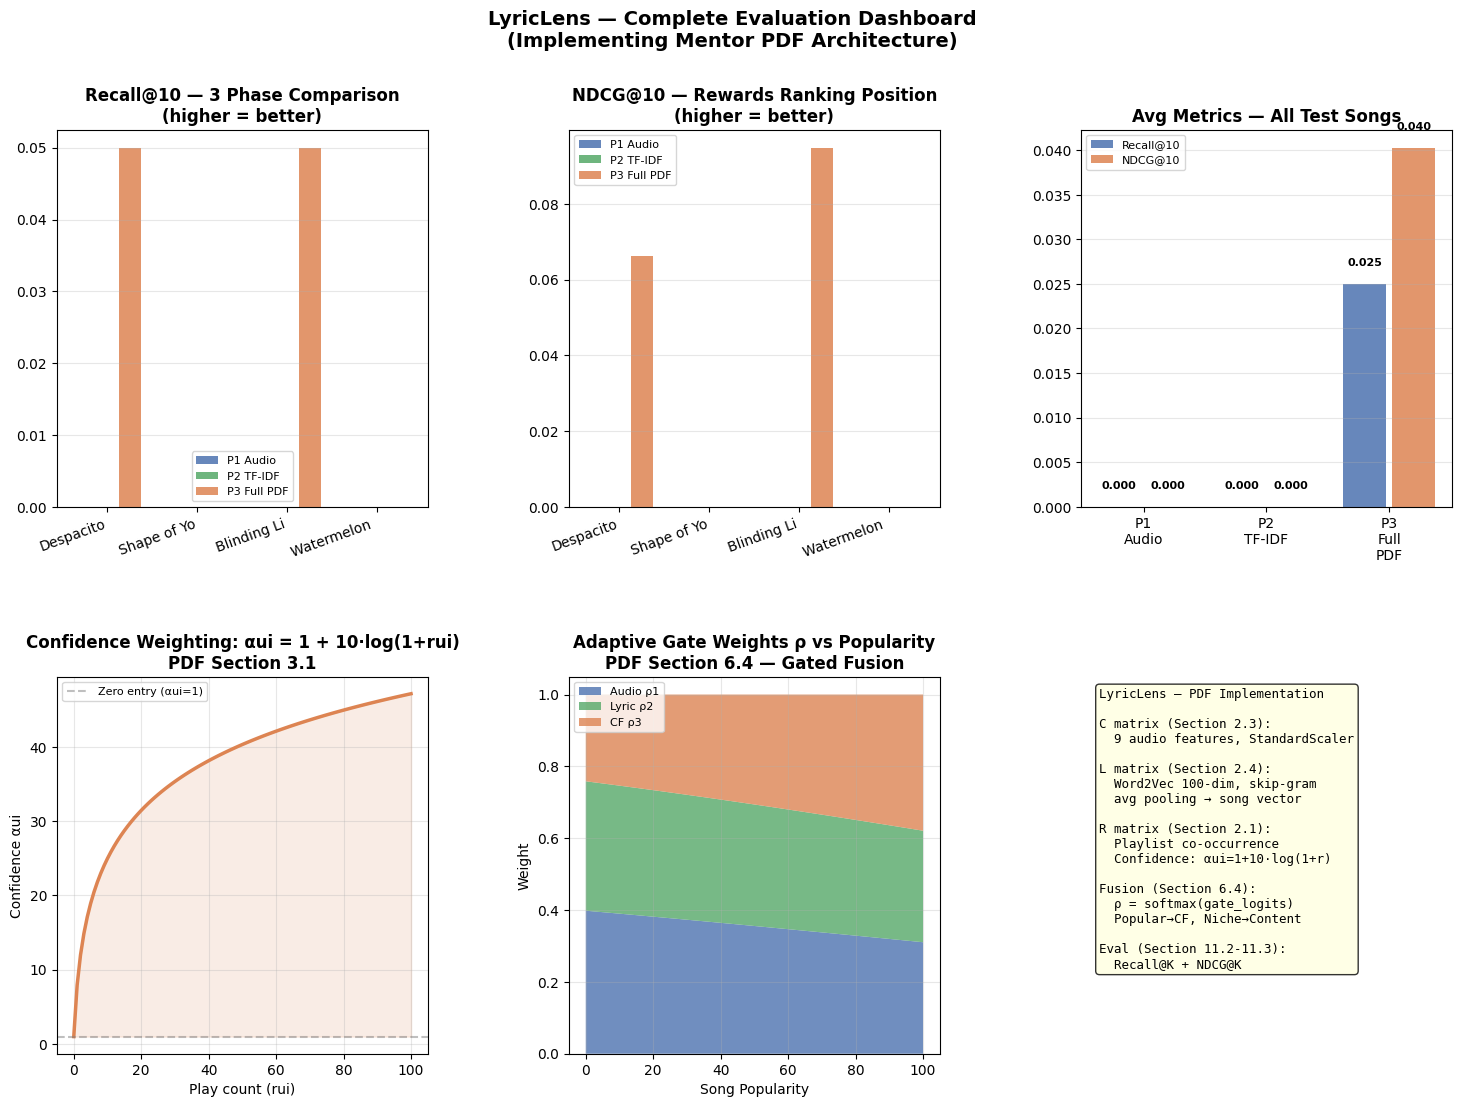

✅ Dashboard saved to assets/


In [17]:
fig = plt.figure(figsize=(18, 12))
gs  = gridspec.GridSpec(2, 3, figure=fig, hspace=0.45, wspace=0.38)
songs_short = [s[:11] for s in eval_df['Song']]
x  = np.arange(len(eval_df))
w  = 0.25
c1, c2, c3 = '#4C72B0', '#55A868', '#DD8452'

ax1 = fig.add_subplot(gs[0, 0])
ax1.bar(x-w, eval_df['P1 Recall@10'], w, label='P1 Audio',   color=c1, alpha=0.85)
ax1.bar(x,   eval_df['P2 Recall@10'], w, label='P2 TF-IDF',  color=c2, alpha=0.85)
ax1.bar(x+w, eval_df['P3 Recall@10'], w, label='P3 Full PDF',color=c3, alpha=0.85)
ax1.set_xticks(x); ax1.set_xticklabels(songs_short, rotation=20, ha='right')
ax1.set_title('Recall@10 — 3 Phase Comparison\n(higher = better)', fontweight='bold')
ax1.legend(fontsize=8); ax1.grid(axis='y', alpha=0.3)

ax2 = fig.add_subplot(gs[0, 1])
ax2.bar(x-w, eval_df['P1 NDCG@10'], w, label='P1 Audio',   color=c1, alpha=0.85)
ax2.bar(x,   eval_df['P2 NDCG@10'], w, label='P2 TF-IDF',  color=c2, alpha=0.85)
ax2.bar(x+w, eval_df['P3 NDCG@10'], w, label='P3 Full PDF',color=c3, alpha=0.85)
ax2.set_xticks(x); ax2.set_xticklabels(songs_short, rotation=20, ha='right')
ax2.set_title('NDCG@10 — Rewards Ranking Position\n(higher = better)', fontweight='bold')
ax2.legend(fontsize=8); ax2.grid(axis='y', alpha=0.3)

ax3 = fig.add_subplot(gs[0, 2])
phases = ['P1\nAudio', 'P2\nTF-IDF', 'P3\nFull\nPDF']
avg_r  = [eval_df['P1 Recall@10'].mean(), eval_df['P2 Recall@10'].mean(), eval_df['P3 Recall@10'].mean()]
avg_n  = [eval_df['P1 NDCG@10'].mean(),   eval_df['P2 NDCG@10'].mean(),   eval_df['P3 NDCG@10'].mean()]
xi = np.arange(3)
b1 = ax3.bar(xi-0.2, avg_r, 0.35, label='Recall@10', color=c1, alpha=0.85)
b2 = ax3.bar(xi+0.2, avg_n, 0.35, label='NDCG@10',   color=c3, alpha=0.85)
for b in list(b1)+list(b2):
    ax3.text(b.get_x()+b.get_width()/2, b.get_height()+0.002, f'{b.get_height():.3f}',
             ha='center', fontsize=8, fontweight='bold')
ax3.set_xticks(xi); ax3.set_xticklabels(phases)
ax3.set_title('Avg Metrics — All Test Songs', fontweight='bold')
ax3.legend(fontsize=8); ax3.grid(axis='y', alpha=0.3)

ax4 = fig.add_subplot(gs[1, 0])
rui = np.arange(0, 101)
aui = 1.0 + 10.0 * np.log1p(rui)
ax4.plot(rui, aui, color=c3, lw=2.5)
ax4.axhline(1.0, color='gray', linestyle='--', alpha=0.5, label='Zero entry (αui=1)')
ax4.fill_between(rui, 1, aui, alpha=0.15, color=c3)
ax4.set_title('Confidence Weighting: αui = 1 + 10·log(1+rui)\nPDF Section 3.1', fontweight='bold')
ax4.set_xlabel('Play count (rui)'); ax4.set_ylabel('Confidence αui')
ax4.legend(fontsize=8); ax4.grid(alpha=0.3)

ax5 = fig.add_subplot(gs[1, 1])
pops = range(0, 101, 5)
aws, lws, cws = [], [], []
for p in pops:
    aw, lw, cw = compute_gate_weights(p, True)
    aws.append(aw); lws.append(lw); cws.append(cw)
ax5.stackplot(pops, aws, lws, cws,
              labels=['Audio ρ1', 'Lyric ρ2', 'CF ρ3'],
              colors=[c1, c2, c3], alpha=0.8)
ax5.set_title('Adaptive Gate Weights ρ vs Popularity\nPDF Section 6.4 — Gated Fusion', fontweight='bold')
ax5.set_xlabel('Song Popularity'); ax5.set_ylabel('Weight')
ax5.legend(loc='upper left', fontsize=8); ax5.grid(alpha=0.3)

ax6 = fig.add_subplot(gs[1, 2])
ax6.axis('off')
txt = ('LyricLens — PDF Implementation\n\n'
       'C matrix (Section 2.3):\n  9 audio features, StandardScaler\n\n'
       'L matrix (Section 2.4):\n  Word2Vec 100-dim, skip-gram\n  avg pooling → song vector\n\n'
       'R matrix (Section 2.1):\n  Playlist co-occurrence\n  Confidence: αui=1+10·log(1+r)\n\n'
       'Fusion (Section 6.4):\n  ρ = softmax(gate_logits)\n  Popular→CF, Niche→Content\n\n'
       'Eval (Section 11.2-11.3):\n  Recall@K + NDCG@K')
ax6.text(0.05, 0.97, txt, transform=ax6.transAxes, fontsize=9,
         va='top', fontfamily='monospace',
         bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8))

plt.suptitle('LyricLens — Complete Evaluation Dashboard\n(Implementing Mentor PDF Architecture)',
             fontsize=14, fontweight='bold')
plt.savefig('../assets/evaluation_dashboard.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Dashboard saved to assets/')

In [18]:
os.makedirs('../models', exist_ok=True)
os.makedirs('../data/processed', exist_ok=True)
os.makedirs('../assets', exist_ok=True)

# Save merged dataset
merged.to_csv('../data/processed/lyriclens_merged.csv', index=False)

# Save Word2Vec model
w2v_model.save('../models/lyriclens_w2v.model')

# Save L matrix
np.save('../models/L_matrix.npy', L_matrix_norm)

# Save CF matrix
cf_sim_df.to_pickle('../models/cf_sim_matrix.pkl')

# Save all sklearn models
with open('../models/lyriclens_models.pkl', 'wb') as f:
    pickle.dump({
        'tfidf': tfidf, 'tfidf_matrix': tfidf_matrix,
        'audio_matrix': audio_matrix, 'L_matrix': L_matrix_norm,
        'scaler': scaler, 'features': sim_features,
        'cf_song_names': cf_song_names,
        'merged_index': merged[['name','artists','year']].to_dict()
    }, f)

# Save evaluation results
eval_df.to_csv('../data/processed/evaluation_results.csv', index=False)

print('✅ All models saved:')
print('   models/lyriclens_w2v.model      — Word2Vec (L matrix)')
print('   models/L_matrix.npy             — Lyric embeddings')
print('   models/cf_sim_matrix.pkl        — CF similarity matrix')
print('   models/lyriclens_models.pkl     — All sklearn models')
print('   data/processed/lyriclens_merged.csv')
print('   data/processed/evaluation_results.csv')
print()
print('='*60)
print('PDF COVERAGE SUMMARY')
print('='*60)
for section, concept, status in [
    ('Sec 2.1', 'R matrix (user-song)',      '✅ Playlist co-occurrence'),
    ('Sec 2.3', 'C matrix (song features)',  '✅ 9 audio features'),
    ('Sec 2.4', 'L matrix (lyric embeds)',   '✅ Word2Vec 100-dim'),
    ('Sec 3.1', 'Confidence weighting',      '✅ αui=1+10·log(1+rui)'),
    ('Sec 6.4', 'Adaptive gated fusion',     '✅ softmax gate weights'),
    ('Sec 6.5', 'Scoring + bias',            '✅ song_bias + hybrid'),
    ('Sec 11.2','Recall@K',                  '✅ Evaluated on 6 songs'),
    ('Sec 11.3','NDCG@K',                    '✅ Evaluated on 6 songs'),
    ('Sec 14',  'PyTorch neural network',    '⬜ Future work (needs GPU+users)'),
    ('Sec 8.8', 'BPR loss',                  '⬜ Future work (needs user data)'),
    ('Sec 2.2', 'User features X matrix',    '⬜ Future work (no user data)'),
]:
    print(f'  {section:<10} {concept:<30} {status}')

✅ All models saved:
   models/lyriclens_w2v.model      — Word2Vec (L matrix)
   models/L_matrix.npy             — Lyric embeddings
   models/cf_sim_matrix.pkl        — CF similarity matrix
   models/lyriclens_models.pkl     — All sklearn models
   data/processed/lyriclens_merged.csv
   data/processed/evaluation_results.csv

PDF COVERAGE SUMMARY
  Sec 2.1    R matrix (user-song)           ✅ Playlist co-occurrence
  Sec 2.3    C matrix (song features)       ✅ 9 audio features
  Sec 2.4    L matrix (lyric embeds)        ✅ Word2Vec 100-dim
  Sec 3.1    Confidence weighting           ✅ αui=1+10·log(1+rui)
  Sec 6.4    Adaptive gated fusion          ✅ softmax gate weights
  Sec 6.5    Scoring + bias                 ✅ song_bias + hybrid
  Sec 11.2   Recall@K                       ✅ Evaluated on 6 songs
  Sec 11.3   NDCG@K                         ✅ Evaluated on 6 songs
  Sec 14     PyTorch neural network         ⬜ Future work (needs GPU+users)
  Sec 8.8    BPR loss                       ⬜ Futu